# Module 03: Heritage Sites & Business Licences Analysis

Exploratory data analysis of Vancouver heritage buildings and business licences data.

**Data:**
- `heritage-sites.csv` — City of Vancouver heritage register
- `business-licences.csv` — City of Vancouver business licences

## 1. Setup and Load Data

In [33]:
# Packages come from uv sync — no pip install needed

In [34]:
import os
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Save figures to file and display (fixes Jupyter Lab matplotlib display)
FIG_DIR = os.path.join(os.getcwd(), 'module-03', 'figures')
if not os.path.isdir(os.path.join(os.getcwd(), 'module-03')):
    FIG_DIR = os.path.join(os.getcwd(), 'figures')
FIG_DIR = os.path.abspath(FIG_DIR)
os.makedirs(FIG_DIR, exist_ok=True)
_fig_count = [0]
from datetime import datetime
def showfig(name='plot'):
    fig = plt.gcf()
    if len(fig.axes) == 0:
        plt.close(fig)
        return
    _fig_count[0] += 1
    ts = datetime.now().strftime('%Y%m%d_%H%M%S')
    path = os.path.join(FIG_DIR, 'fig_{:02d}_{}_{}.png'.format(_fig_count[0], name, ts))
    fig.savefig(path, dpi=120, bbox_inches='tight')
    display(Image(filename=path))
    plt.close(fig)
plt.show = lambda: showfig('plot')
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Colab: upload file if not found
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Try paths for both: notebook in module-03, or Cursor running from project root
FILE_PATH = None
for path in ['heritage-sites.csv', 'module-03/heritage-sites.csv']:
    if os.path.exists(path):
        FILE_PATH = path
        break

if FILE_PATH is None and IN_COLAB:
    print('Please upload heritage-sites.csv')
    uploaded = files.upload()
    FILE_PATH = list(uploaded.keys())[0]
elif FILE_PATH is None:
    raise FileNotFoundError(
        "Could not find heritage-sites.csv. "
        "Ensure the CSV is in module-03/ or run the notebook from the project root."
    )

df = pd.read_csv(FILE_PATH, sep=';')
print(f'Heritage sites: {len(df):,} rows, {len(df.columns)} columns')

# Load business licences
BIZ_PATH = None
for path in ['business-licences.csv', 'module-03/business-licences.csv']:
    if os.path.exists(path):
        BIZ_PATH = path
        break
if BIZ_PATH is None and IN_COLAB:
    print('Please upload business-licences.csv')
    uploaded = files.upload()
    BIZ_PATH = list(uploaded.keys())[0]
elif BIZ_PATH is None:
    raise FileNotFoundError("Could not find business-licences.csv")
df_biz = pd.read_csv(BIZ_PATH, sep=';')
print(f'Business licences: {len(df_biz):,} rows, {len(df_biz.columns)} columns')

print('\n--- Heritage sites (first 5 rows) ---')
df.head()

Heritage sites: 2,495 rows, 20 columns
Business licences: 197,494 rows, 25 columns

--- Heritage sites (first 5 rows) ---


,ID,StreetNumber,StreetName,AdditionalLocationInformation,Category,BuildingNameSpecifics,EvaluationGroup,MunicipalDesignationM,ProvincialDesignationP,HeritageRevitalizationAgreementH,InteriorDesignationI,LandscapeDesignationL,HeritageConservationAreaCA,HeritageConservationCovenantHC,FederalDesignationF,Status,DateofLastUpdate,LocalArea,Geom,geo_point_2d
0,540,212,E 38TH AV,NaN,HERITAGE BUILDINGS,Lawson-Logie House,C,Yes,No,Yes,No,No,No,No,No,Active,2020-09-18T10:18:45-07:00,Riley Park,"{""coordinates"": [-123.10108312373846, 49.23619...","49.236191013848334, -123.10108312373846"
1,542,728,E 39TH AV,NaN,HERITAGE BUILDINGS,NaN,C,No,No,No,No,No,No,No,No,Active,2020-09-18T10:18:45-07:00,Kensington-Cedar Cottage,"{""coordinates"": [-123.08966751689462, 49.23454...","49.23454205176911, -123.08966751689462"
2,545,1937,E 3RD AV,NaN,HERITAGE BUILDINGS,St. Pierre House,C,No,No,No,No,No,No,No,No,Active,2020-09-18T10:18:45-07:00,Grandview-Woodland,"{""coordinates"": [-123.06488631964011, 49.26801...","49.26801090366661, -123.06488631964011"
3,550,530,E 41ST AV,NaN,HERITAGE BUILDINGS,John Oliver School #5,B,No,No,No,No,No,No,No,No,Active,2020-09-18T10:18:45-07:00,Sunset,"{""coordinates"": [-123.09260325966693, 49.23194...","49.23194909033478, -123.09260325966693"
4,554,3326,E 44TH AV,NaN,HERITAGE BUILDINGS,NaN,B,No,No,No,No,No,No,No,No,Active,2020-09-18T10:18:45-07:00,Killarney,"{""coordinates"": [-123.03389151485587, 49.22980...","49.229803926941464, -123.03389151485587"


In [35]:
df_biz.head()

,FOLDERYEAR,LicenceRSN,LicenceNumber,LicenceRevisionNumber,BusinessName,BusinessTradeName,Status,IssuedDate,ExpiredDate,BusinessType,...,City,Province,Country,PostalCode,LocalArea,NumberofEmployees,FeePaid,ExtractDate,Geom,geo_point_2d
0,25,4616252,25-108531,0,648039 BC Ltd,Roxy Burger,Issued,2024-12-02T13:09:55-08:00,2025-12-31,Restaurant,...,Vancouver,BC,CA,V6Z 1L2,Downtown,20.0,2088.0,2026-02-01T02:33:15-08:00,"{""coordinates"": [-123.12147734521, 49.27988335...","49.2798833507362, -123.12147734521"
1,25,4616265,25-108544,0,Hie Hotel Vancouver Inc,Atrium Inn Vancouver,Gone Out of Business,2024-12-04T11:39:43-08:00,2025-12-31,Restaurant,...,Vancouver,BC,CA,V5K 2A1,Hastings-Sunrise,0.0,3794.0,2026-02-01T02:33:15-08:00,"{""coordinates"": [-123.04555100057, 49.28140548...","49.2814054837269, -123.04555100057"
2,25,4616269,25-108548,0,Baan Wasana Thai Restaurant Inc,Baan Wasana Thai Restaurant,Issued,2024-12-08T11:12:55-08:00,2025-12-31,Restaurant,...,Vancouver,BC,CA,V6M 1Z6,Arbutus-Ridge,10.0,1524.0,2026-02-01T02:33:15-08:00,"{""coordinates"": [-123.156748642132, 49.2348517...","49.2348517158637, -123.156748642132"
3,25,4616270,25-108549,0,Potato Planet Restaurant Inc,Belgian Fries,Issued,2024-11-18T11:35:33-08:00,2025-12-31,Restaurant,...,Vancouver,BC,CA,V5N 4A6,Grandview-Woodland,10.0,1724.0,2026-02-01T02:33:15-08:00,"{""coordinates"": [-123.07015733446, 49.26804931...","49.2680493162521, -123.07015733446"
4,25,4616271,25-108550,0,Northland Properties Corporation,Moxie's,Gone Out of Business,NaN,NaN,Restaurant,...,Vancouver,BC,CA,V6E 1N1,West End,32.0,NaN,2026-02-01T02:33:15-08:00,"{""coordinates"": [-123.132546695562, 49.2808410...","49.2808410078758, -123.132546695562"


## 2. Data Overview

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2495 entries, 0 to 2494
Data columns (total 20 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   ID                                2495 non-null   int64 
 1   StreetNumber                      2414 non-null   object
 2   StreetName                        2414 non-null   object
 3   AdditionalLocationInformation     86 non-null     object
 4   Category                          2495 non-null   object
 5   BuildingNameSpecifics             1064 non-null   object
 6   EvaluationGroup                   2263 non-null   object
 7   MunicipalDesignationM             2495 non-null   object
 8   ProvincialDesignationP            2495 non-null   object
 9   HeritageRevitalizationAgreementH  2495 non-null   object
 10  InteriorDesignationI              2495 non-null   object
 11  LandscapeDesignationL             2495 non-null   object
 12  HeritageConservation

In [37]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,2495.0,NaN,NaN,NaN,1316.93988,756.181298,1.0,661.5,1325.0,1967.5,2625.0
StreetNumber,2414,1827,2050,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StreetName,2414,312,E PENDER ST,91,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AdditionalLocationInformation,86,80,Stanley Park,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,2495,7,HERITAGE BUILDINGS,2359,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BuildingNameSpecifics,1064,1025,"General Activity, Shell Midden",14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EvaluationGroup,2263,3,B,1173,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MunicipalDesignationM,2495,4,No,1808,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ProvincialDesignationP,2495,3,No,2492,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HeritageRevitalizationAgreementH,2495,3,No,2276,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2b. Data Quality Analysis

Missing values, outliers, and inconsistencies.

In [38]:
# --- Missing values ---
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct}).sort_values('count', ascending=False)
print('Missing values by column:')
print(missing_df[missing_df['count'] > 0].to_string())
print(f'\nColumns with no missing: {(missing == 0).sum()}')

# --- Inconsistencies: linked missingness ---
addr_missing = (df['StreetNumber'].isna() & df['StreetName'].isna()).sum()
print(f'\n--- Linked missingness ---\nRows missing both StreetNumber and StreetName: {addr_missing} (likely non-address sites: parks, landscapes)')

# --- Duplicates ---
dup_ids = df['ID'].duplicated().sum()
print(f'\n--- Duplicates ---\nDuplicate IDs: {dup_ids}')

# --- Outliers: coordinates ---
coords = df['geo_point_2d'].str.split(',', expand=True)
_lat = pd.to_numeric(coords[0], errors='coerce')
_lon = pd.to_numeric(coords[1], errors='coerce')
coord_na = _lat.isna().sum()
valid = ~_lat.isna()
print(f'\n--- Geographic ---\nMissing coordinates: {coord_na} rows')
if valid.sum() > 0:
    print(f'Latitude range: {_lat[valid].min():.4f} to {_lat[valid].max():.4f} (Vancouver ~49.2°N)')
    print(f'Longitude range: {_lon[valid].min():.4f} to {_lon[valid].max():.4f} (~123.1°W)')

# --- Categorical consistency ---
print('\n--- Categorical checks ---')
print('EvaluationGroup:', df['EvaluationGroup'].value_counts(dropna=False).to_dict())
print('Status:', df['Status'].unique())
design_cols = ['MunicipalDesignationM', 'ProvincialDesignationP', 'FederalDesignationF']
for c in design_cols:
    print(f'{c}: {df[c].value_counts().to_dict()}')

# --- Patterns ---
print('\n--- Patterns ---')
print('• AdditionalLocationInformation: 96.6% missing — optional; when present, describes landmarks (e.g. Stanley Park)')
print('• BuildingNameSpecifics: 57% missing — many sites have no specific building name')
print('• EvaluationGroup: 232 missing — unclassified sites; A/B/C = significance tiers')
print('• StreetNumber/StreetName: 81 rows missing both — non-address sites (e.g. heritage landscapes)')
print('• Geom/geo_point_2d: 136 missing — sites without coordinates')
print('• Status: all Active — snapshot contains no retired sites')

Missing values by column:
                               count   pct
AdditionalLocationInformation   2409  96.6
BuildingNameSpecifics           1431  57.4
EvaluationGroup                  232   9.3
LocalArea                        142   5.7
geo_point_2d                     136   5.5
Geom                             136   5.5
StreetName                        81   3.2
StreetNumber                      81   3.2

Columns with no missing: 12

--- Linked missingness ---
Rows missing both StreetNumber and StreetName: 81 (likely non-address sites: parks, landscapes)

--- Duplicates ---
Duplicate IDs: 0

--- Geographic ---
Missing coordinates: 136 rows
Latitude range: 49.2064 to 49.3045 (Vancouver ~49.2°N)
Longitude range: -123.2219 to -123.0238 (~123.1°W)

--- Categorical checks ---
EvaluationGroup: {'B': 1173, 'C': 818, 'A': 272, nan: 232}
Status: ['Active']
MunicipalDesignationM: {'No': 1808, 'Yes': 684, 'Y': 2, 'N': 1}
ProvincialDesignationP: {'No': 2492, 'N': 2, 'Yes': 1}
FederalDesignati

## 2c. Data Quality Report

Formal metrics, severity ranking, and recommendations.

In [39]:
n = len(df)

# --- Metrics ---
completeness = (1 - df.isnull().sum() / n) * 100
overall_completeness = (1 - df.isnull().sum().sum() / (n * len(df.columns))) * 100

# Critical columns for core analyses
critical_cols = {'geo_point_2d': 'Spatial', 'LocalArea': 'Area aggregation', 'StreetNumber': 'Address', 
                 'EvaluationGroup': 'Significance stratification'}
critical_completeness = {col: completeness[col] for col in critical_cols if col in df.columns}

# Categorical consistency: Yes/No vs Y/N
yn_cols = ['MunicipalDesignationM', 'ProvincialDesignationP', 'FederalDesignationF']
inconsistent = {}
for c in yn_cols:
    if c in df.columns:
        non_std = df[c].isin(['Y', 'N']).sum()
        if non_std > 0:
            inconsistent[c] = non_std

# --- Report ---
print('=' * 60)
print('DATA QUALITY REPORT: heritage-sites.csv')
print('=' * 60)
print(f'\nDataset: {n:,} rows, {len(df.columns)} columns')
print(f'Overall completeness: {overall_completeness:.1f}% (non-null cells)')
print('\n--- COMPLETENESS BY CRITICAL COLUMN ---')
for col, use in critical_cols.items():
    pct = critical_completeness.get(col, 0)
    status = 'OK' if pct >= 95 else 'WARNING' if pct >= 80 else 'CRITICAL'
    print(f'  {col:25} {pct:5.1f}%  [{use}]  {status}')

print('\n--- CONSISTENCY ISSUES ---')
if inconsistent:
    for col, count in inconsistent.items():
        print(f'  {col}: {count} rows with Y/N instead of Yes/No')
else:
    print('  No Yes/No inconsistencies detected')

print('\n--- SEVERITY-RANKED ISSUES ---')
issues = [
    ('HIGH', 'Missing coordinates (geo_point_2d)', 136, 5.5, 'Exclude from spatial analysis or attempt geocoding'),
    ('HIGH', 'Missing LocalArea', 142, 5.7, 'Exclude from area aggregations or impute from coordinates'),
    ('HIGH', 'Missing StreetNumber/StreetName (both)', 81, 3.2, 'Flag as non-address sites; exclude from address joins'),
    ('MEDIUM', 'Missing EvaluationGroup', 232, 9.3, 'Create "Unclassified" category or exclude from significance analysis'),
    ('MEDIUM', 'Y/N vs Yes/No in designation columns', sum(inconsistent.values()), 
     round(sum(inconsistent.values()) / (n * len(yn_cols)) * 100, 2) if inconsistent else 0, 
     'Standardize to Yes/No before analysis'),
    ('LOW', 'Missing BuildingNameSpecifics', 1431, 57.4, 'Accept for aggregate analysis; flag for text/name analysis'),
    ('LOW', 'Missing AdditionalLocationInformation', 2409, 96.6, 'Optional field; no action for most analyses'),
]
for sev, desc, cnt, pct, rec in issues:
    pct_str = f' ({pct}%)' if pct else ''
    print(f'  [{sev:6}] {desc}: {cnt} rows{pct_str}')
    print(f'          → {rec}')

print('\n--- RECOMMENDATIONS ---')
print('  1. For spatial analysis: filter to rows with valid geo_point_2d (n ≈ 2,359)')
print('  2. For area analysis: filter to rows with valid LocalArea, or impute from lat/lon if available')
print('  3. Standardize designation columns: map Y→Yes, N→No before any Yes/No aggregation')
print('  4. Document exclusion criteria: report n excluded and reason in any analysis')
print('  5. Consider data source update: request complete coordinates/LocalArea from City of Vancouver')
print('=' * 60)

DATA QUALITY REPORT: heritage-sites.csv

Dataset: 2,495 rows, 20 columns
Overall completeness: 90.7% (non-null cells)

--- COMPLETENESS BY CRITICAL COLUMN ---
  geo_point_2d               94.5%  [Spatial]  WARNING
  LocalArea                  94.3%  [Area aggregation]  WARNING
  StreetNumber               96.8%  [Address]  OK
  EvaluationGroup            90.7%  [Significance stratification]  WARNING

--- CONSISTENCY ISSUES ---
  MunicipalDesignationM: 3 rows with Y/N instead of Yes/No
  ProvincialDesignationP: 2 rows with Y/N instead of Yes/No
  FederalDesignationF: 2 rows with Y/N instead of Yes/No

--- SEVERITY-RANKED ISSUES ---
  [HIGH  ] Missing coordinates (geo_point_2d): 136 rows (5.5%)
          → Exclude from spatial analysis or attempt geocoding
  [HIGH  ] Missing LocalArea: 142 rows (5.7%)
          → Exclude from area aggregations or impute from coordinates
  [HIGH  ] Missing StreetNumber/StreetName (both): 81 rows (3.2%)
          → Flag as non-address sites; exclude from a

*Missing values*
- Counts and percentages by column
- Columns with the most missing data: AdditionalLocationInformation (96.6%), BuildingNameSpecifics (57%), EvaluationGroup (9.3%), - LocalArea (5.7%), and Geom/geo_point_2d (5.4%)

*Inconsistencies*
81 rows missing both StreetNumber and StreetName (likely non-address sites such as parks or landscapes)
136 rows missing coordinates

*Outliers*
Geographic bounds for valid coordinates (Vancouver area)

*Patterns*
AdditionalLocationInformation is optional and mostly empty
BuildingNameSpecifics is often missing for unnamed buildings
EvaluationGroup has 232 unclassified sites (A/B/C = significance tiers)
All records have Status = Active (no retired sites)
Designation columns are consistently Yes/No
Run the new cells to view the full output.

## 2d. Data Preparation (Implement Recommendations)

Apply fixes from the data quality report for downstream analysis.

In [40]:
# Copy for cleaning (preserve original df)
df_clean = df.copy()

# 1. Standardize Y/N → Yes/No in designation columns
yn_cols = ['MunicipalDesignationM', 'ProvincialDesignationP', 'FederalDesignationF',
           'HeritageRevitalizationAgreementH', 'InteriorDesignationI', 'LandscapeDesignationL',
           'HeritageConservationAreaCA', 'HeritageConservationCovenantHC']
yn_cols = [c for c in yn_cols if c in df_clean.columns]
for col in yn_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].replace({'Y': 'Yes', 'N': 'No'})
print('1. Standardized Y/N → Yes/No in designation columns')

# 2. Parse coordinates for spatial analysis
coords = df_clean['geo_point_2d'].str.split(',', expand=True)
df_clean['lat'] = pd.to_numeric(coords[0], errors='coerce')
df_clean['lon'] = pd.to_numeric(coords[1], errors='coerce')
df_clean['has_coords'] = df_clean['lat'].notna()
print(f'2. Parsed coordinates: {df_clean["has_coords"].sum():,} rows with valid lat/lon')

# 3. Create analysis-ready subsets
df_spatial = df_clean[df_clean['has_coords']].copy()
df_area = df_clean[df_clean['LocalArea'].notna()].copy()
print(f'3. df_spatial (for maps/distance): {len(df_spatial):,} rows')
print(f'   df_area (for area aggregations): {len(df_area):,} rows')

# 4. Fill missing EvaluationGroup with "Unclassified"
n_unclass = df_clean['EvaluationGroup'].isna().sum()
df_clean['EvaluationGroup'] = df_clean['EvaluationGroup'].fillna('Unclassified')
print(f'4. Filled {n_unclass} missing EvaluationGroup with "Unclassified"')

# 5. Flag non-address sites
df_clean['has_address'] = df_clean['StreetNumber'].notna() & df_clean['StreetName'].notna()
print(f'5. Flagged non-address sites: {(~df_clean["has_address"]).sum()} rows (has_address=False)')

print(f'\nReady: df_clean ({len(df_clean):,} rows), df_spatial ({len(df_spatial):,}), df_area ({len(df_area):,})')

1. Standardized Y/N → Yes/No in designation columns
2. Parsed coordinates: 2,359 rows with valid lat/lon
3. df_spatial (for maps/distance): 2,359 rows
   df_area (for area aggregations): 2,353 rows
4. Filled 232 missing EvaluationGroup with "Unclassified"
5. Flagged non-address sites: 81 rows (has_address=False)

Ready: df_clean (2,495 rows), df_spatial (2,359), df_area (2,353)


## 3. Key Variables Analysis

Top 15 local areas by heritage site count:
LocalArea
Kitsilano                   487
Downtown                    409
Strathcona                  261
Mount Pleasant              206
Grandview-Woodland          136
West End                    135
Kensington-Cedar Cottage    112
Shaughnessy                 111
Fairview                     82
Riley Park                   76
Hastings-Sunrise             62
Kerrisdale                   60
West Point Grey              52
South Cambie                 35
Dunbar-Southlands            34
Name: count, dtype: int64


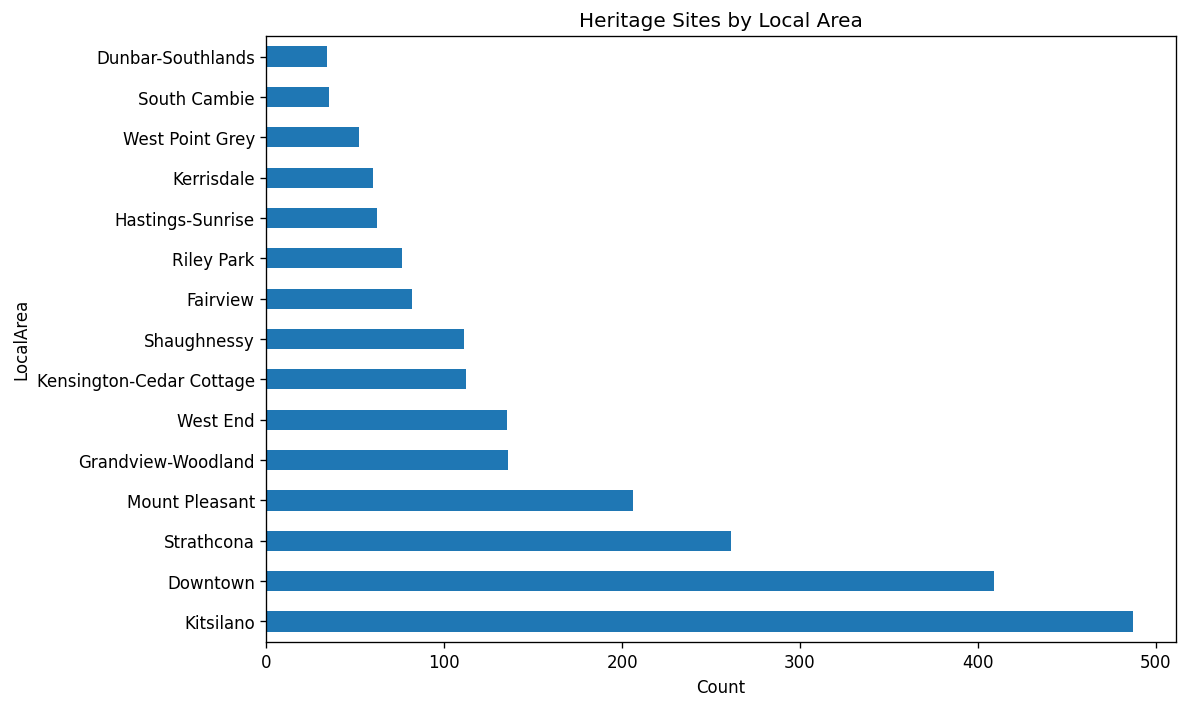

In [41]:
# Heritage sites by local area
area_counts = df['LocalArea'].value_counts()
print('Top 15 local areas by heritage site count:')
print(area_counts.head(15))

area_counts.head(15).plot(kind='barh', figsize=(10, 6), title='Heritage Sites by Local Area')
plt.xlabel('Count')
plt.tight_layout()
showfig('heritage_area')

Evaluation groups (A=highest significance, C=contributing):
EvaluationGroup
B      1173
C       818
A       272
NaN     232
Name: count, dtype: int64


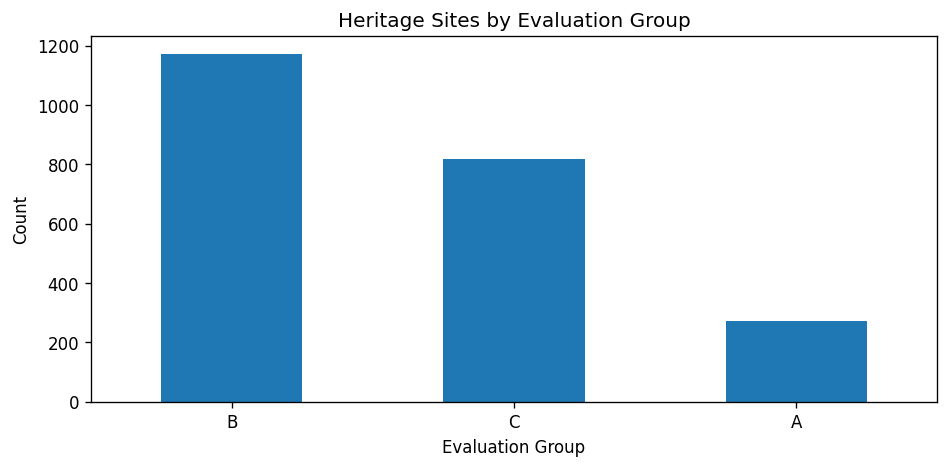

In [42]:
# Evaluation group distribution
print('Evaluation groups (A=highest significance, C=contributing):')
print(df['EvaluationGroup'].value_counts(dropna=False))

df['EvaluationGroup'].value_counts().plot(kind='bar', figsize=(8, 4), title='Heritage Sites by Evaluation Group')
plt.xlabel('Evaluation Group')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
showfig('eval_group')

In [43]:
# Designation types
designation_cols = ['MunicipalDesignationM', 'ProvincialDesignationP', 'FederalDesignationF']
for col in designation_cols:
    if col in df.columns:
        print(f'\n{col}:')
        print(df[col].value_counts())


MunicipalDesignationM:
MunicipalDesignationM
No     1808
Yes     684
Y         2
N         1
Name: count, dtype: int64

ProvincialDesignationP:
ProvincialDesignationP
No     2492
N         2
Yes       1
Name: count, dtype: int64

FederalDesignationF:
FederalDesignationF
No     2479
Yes      14
N         2
Name: count, dtype: int64


## 4. Geographic Summary

In [44]:
# Parse coordinates from geo_point_2d if available
if 'geo_point_2d' in df.columns:
    coords = df['geo_point_2d'].str.split(',', expand=True)
    if coords.shape[1] >= 2:
        df['lat'] = pd.to_numeric(coords[0], errors='coerce')
        df['lon'] = pd.to_numeric(coords[1], errors='coerce')
        print('Coordinate range:')
        print(f"  Latitude:  {df['lat'].min():.4f} to {df['lat'].max():.4f}")
        print(f"  Longitude: {df['lon'].min():.4f} to {df['lon'].max():.4f}")
        print(f"  (Vancouver area: ~49.2°N, ~123.1°W)")

Coordinate range:
  Latitude:  49.2064 to 49.3045
  Longitude: -123.2219 to -123.0238
  (Vancouver area: ~49.2°N, ~123.1°W)


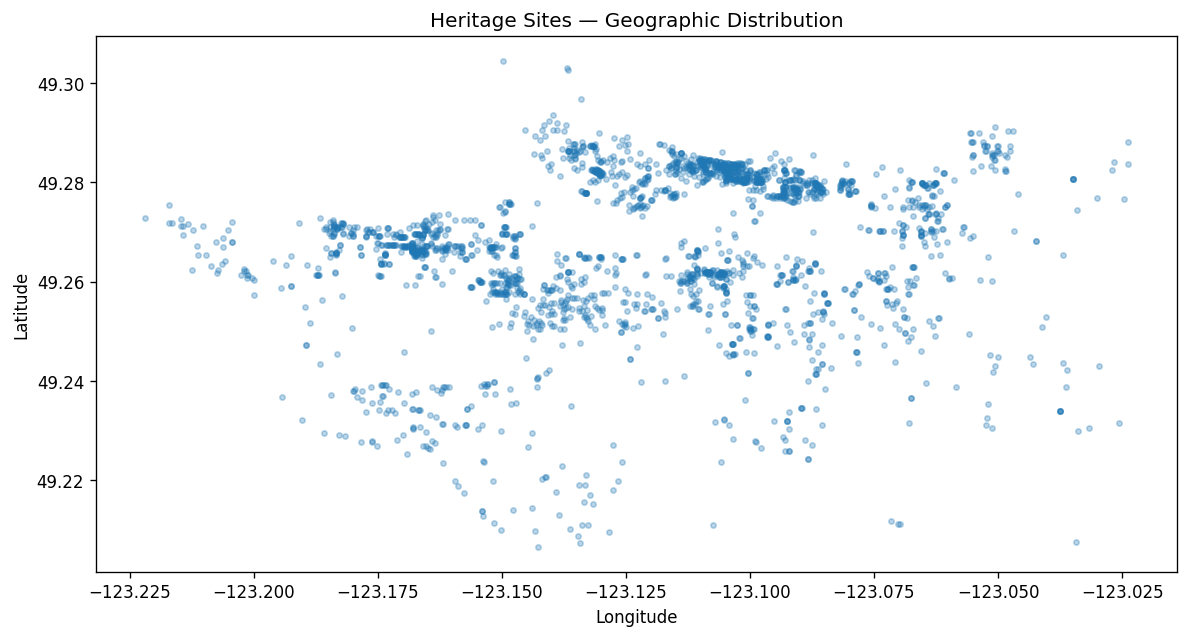

In [45]:
# Simple scatter of heritage sites (if coordinates parsed)
if 'lat' in df.columns and 'lon' in df.columns:
    df_geo = df.dropna(subset=['lat', 'lon'])
    plt.figure(figsize=(10, 8))
    plt.scatter(df_geo['lon'], df_geo['lat'], alpha=0.3, s=10)
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('Heritage Sites — Geographic Distribution')
    plt.gca().set_aspect('equal')
    plt.tight_layout()
    showfig('plot')

## 5. Summary Statistics

In [46]:
print('=== Heritage Sites Summary ===')
print(f'Total sites: {len(df):,}')
print(f'Unique local areas: {df["LocalArea"].nunique()}')
print(f'Categories: {df["Category"].unique().tolist()}')
print(f'Municipal designations: {(df["MunicipalDesignationM"] == "Yes").sum():,}')
print(f'Provincial designations: {(df["ProvincialDesignationP"] == "Yes").sum():,}')
print(f'Federal designations: {(df["FederalDesignationF"] == "Yes").sum():,}')

=== Heritage Sites Summary ===
Total sites: 2,495
Unique local areas: 22
Categories: ['HERITAGE BUILDINGS', 'LANDSCAPE RESOURCES Parks & Landscapes', 'LANDSCAPE RESOURCES Trees', 'ARCHAEOLOGICAL SITES', 'LANDSCAPE RESOURCES Monuments', 'LANDSCAPE RESOURCES Public Works', 'HERITAGE STREETSCAPES']
Municipal designations: 684
Provincial designations: 1
Federal designations: 14


## 6. Business Licences — Data Overview

In [47]:
df_biz.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197494 entries, 0 to 197493
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   FOLDERYEAR             197494 non-null  int64  
 1   LicenceRSN             197494 non-null  int64  
 2   LicenceNumber          197494 non-null  object 
 3   LicenceRevisionNumber  197494 non-null  int64  
 4   BusinessName           185225 non-null  object 
 5   BusinessTradeName      74624 non-null   object 
 6   Status                 197494 non-null  object 
 7   IssuedDate             166799 non-null  object 
 8   ExpiredDate            166821 non-null  object 
 9   BusinessType           197494 non-null  object 
 10  BusinessSubType        20440 non-null   object 
 11  Unit                   47488 non-null   object 
 12  UnitType               47232 non-null   object 
 13  House                  106565 non-null  object 
 14  Street                 106582 non-nu

In [48]:
df_biz.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
FOLDERYEAR,197494.0,NaN,NaN,NaN,25.008375,0.803797,24.0,24.0,25.0,26.0,26.0
LicenceRSN,197494.0,NaN,NaN,NaN,4677025.603198,146912.469181,4322434.0,4527662.25,4644720.5,4839169.75,4941205.0
LicenceNumber,197494,192803,25-108207,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LicenceRevisionNumber,197494.0,NaN,NaN,NaN,2.674861,4.424152,0.0,0.0,0.0,10.0,12.0
BusinessName,185225,58503,Parking Corporation of Vancouver,504,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BusinessTradeName,74624,22770,Lawson Lundell LLP,214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Status,197494,5,Issued,160003,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IssuedDate,166799,153311,2026-01-07T13:54:43-08:00,51,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ExpiredDate,166821,416,2024-12-31,58520,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BusinessType,197494,94,Long-term Rental,44566,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 6b. Business Licences — Data Quality

Missing values, duplicates, and coordinate checks.

In [49]:
# Missing values
missing_biz = df_biz.isnull().sum()
missing_biz_pct = (missing_biz / len(df_biz) * 100).round(1)
missing_biz_df = pd.DataFrame({'count': missing_biz, 'pct': missing_biz_pct}).sort_values('count', ascending=False)
print('Missing values by column:')
print(missing_biz_df[missing_biz_df['count'] > 0].head(15).to_string())
print(f'\nColumns with no missing: {(missing_biz == 0).sum()}')

# Duplicates
dup_rsn = df_biz['LicenceRSN'].duplicated().sum()
print(f'\n--- Duplicates ---\nDuplicate LicenceRSN: {dup_rsn}')

# Coordinates
if 'geo_point_2d' in df_biz.columns:
    coords_biz = df_biz['geo_point_2d'].str.split(',', expand=True)
    lat_biz = pd.to_numeric(coords_biz[0], errors='coerce')
    lon_biz = pd.to_numeric(coords_biz[1], errors='coerce')
    coord_na_biz = lat_biz.isna().sum()
    valid_biz = ~lat_biz.isna()
    print(f'\n--- Geographic ---\nMissing coordinates: {coord_na_biz} rows ({100*coord_na_biz/len(df_biz):.1f}%)')
    if valid_biz.sum() > 0:
        print(f'Latitude range: {lat_biz[valid_biz].min():.4f} to {lat_biz[valid_biz].max():.4f}')
        print(f'Longitude range: {lon_biz[valid_biz].min():.4f} to {lon_biz[valid_biz].max():.4f}')

Missing values by column:
                    count   pct
BusinessSubType    177054  89.7
UnitType           150262  76.1
Unit               150006  76.0
BusinessTradeName  122870  62.2
Geom                97992  49.6
geo_point_2d        97992  49.6
PostalCode          91665  46.4
House               90929  46.0
Street              90912  46.0
FeePaid             77013  39.0
Country             40303  20.4
IssuedDate          30695  15.5
ExpiredDate         30673  15.5
BusinessName        12269   6.2
LocalArea            2719   1.4

Columns with no missing: 8

--- Duplicates ---
Duplicate LicenceRSN: 3

--- Geographic ---
Missing coordinates: 97992 rows (49.6%)
Latitude range: 49.2005 to 49.2981
Longitude range: -123.2192 to -123.0240


## 7. Business Licences — Key Variables

Business type, status, and local area distributions.

Top 15 local areas by business licence count:
LocalArea
Downtown                    47022
Fairview                    15448
Out of Town                 13430
Kitsilano                   12777
Mount Pleasant              12276
West End                    10456
Kensington-Cedar Cottage    10102
Grandview-Woodland           8297
Renfrew-Collingwood          8156
Sunset                       7165
Marpole                      6726
Hastings-Sunrise             6446
Riley Park                   6275
Strathcona                   6176
Victoria-Fraserview          4006
Name: count, dtype: int64


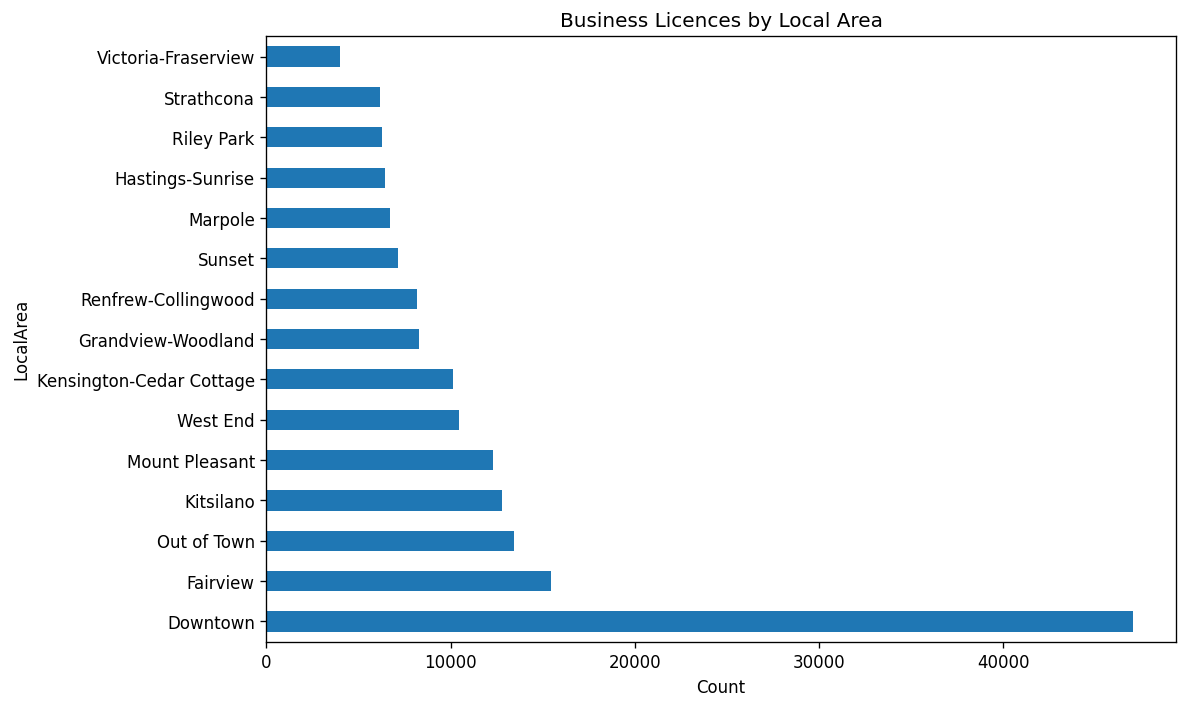

In [50]:
# Business licences by local area
if 'LocalArea' in df_biz.columns:
    area_counts_biz = df_biz['LocalArea'].value_counts()
    print('Top 15 local areas by business licence count:')
    print(area_counts_biz.head(15))
    area_counts_biz.head(15).plot(kind='barh', figsize=(10, 6), title='Business Licences by Local Area')
    plt.xlabel('Count')
    plt.tight_layout()
    showfig('plot')

Licence status:
Status
Issued                  160003
Pending                  20176
Gone Out of Business      7728
Inactive                  5157
Cancelled                 4430
Name: count, dtype: int64


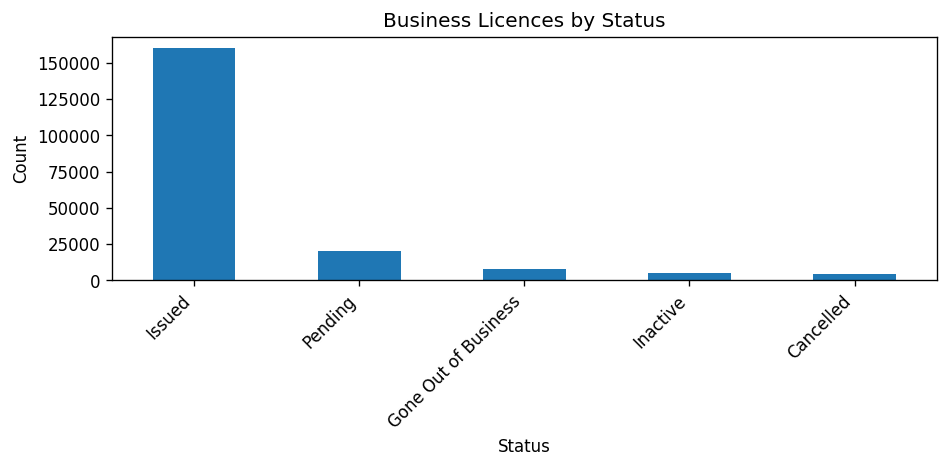

In [51]:
# Status distribution
if 'Status' in df_biz.columns:
    print('Licence status:')
    print(df_biz['Status'].value_counts(dropna=False))
    df_biz['Status'].value_counts().plot(kind='bar', figsize=(8, 4), title='Business Licences by Status')
    plt.xlabel('Status')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    showfig('plot')

Top 15 business types:
BusinessType
Long-term Rental                          44566
Health Care Professionals and Services    18017
General Contractor                        15451
Short-term Rental Operator                12222
Retail Dealer                              9199
Consulting and Management Services         7065
Trade Contractor                           6508
Legal Services                             6298
Restaurant                                 6030
Beauty Services                            5235
Business Support Services                  4990
Limited Service Food Establishment         4659
Financial Services                         3635
Information Communication Technology       3483
Real Estate Services                       3286
Name: count, dtype: int64


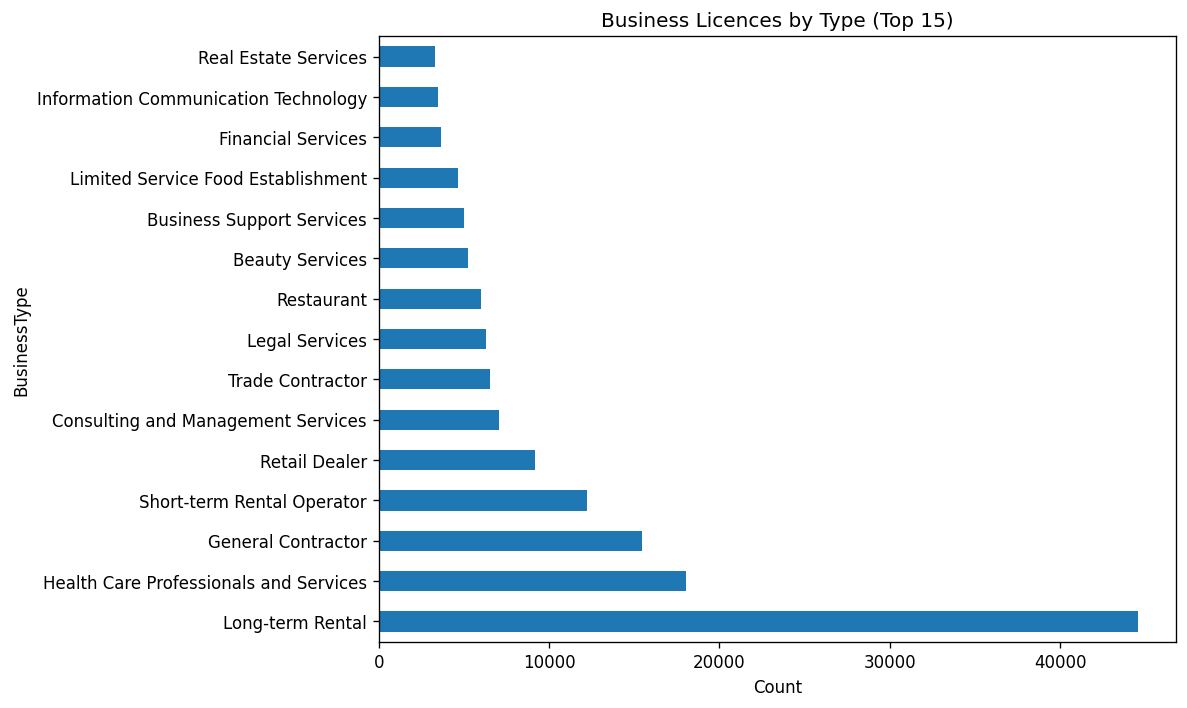

In [52]:
# Business type distribution (top 15)
if 'BusinessType' in df_biz.columns:
    print('Top 15 business types:')
    print(df_biz['BusinessType'].value_counts().head(15))
    df_biz['BusinessType'].value_counts().head(15).plot(kind='barh', figsize=(10, 6), title='Business Licences by Type (Top 15)')
    plt.xlabel('Count')
    plt.tight_layout()
    showfig('biz_type')

## 8. Business Licences — Geographic Summary

Coordinate range: 99,502 licences with valid coordinates
  Latitude:  49.2005 to 49.2981
  Longitude: -123.2192 to -123.0240


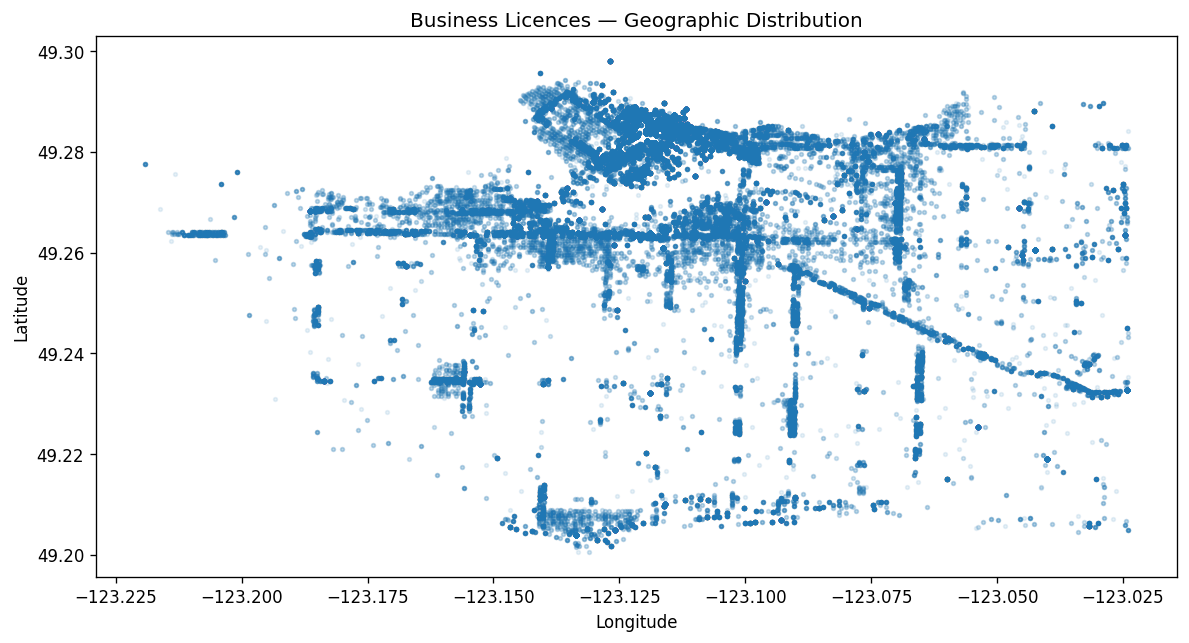

In [53]:
# Parse coordinates and plot geographic distribution
if 'geo_point_2d' in df_biz.columns:
    coords_biz = df_biz['geo_point_2d'].str.split(',', expand=True)
    df_biz_geo = df_biz.copy()
    df_biz_geo['lat'] = pd.to_numeric(coords_biz[0], errors='coerce')
    df_biz_geo['lon'] = pd.to_numeric(coords_biz[1], errors='coerce')
    df_biz_valid = df_biz_geo.dropna(subset=['lat', 'lon'])
    if len(df_biz_valid) > 0:
        print(f'Coordinate range: {len(df_biz_valid):,} licences with valid coordinates')
        print(f"  Latitude:  {df_biz_valid['lat'].min():.4f} to {df_biz_valid['lat'].max():.4f}")
        print(f"  Longitude: {df_biz_valid['lon'].min():.4f} to {df_biz_valid['lon'].max():.4f}")
        plt.figure(figsize=(10, 8))
        plt.scatter(df_biz_valid['lon'], df_biz_valid['lat'], alpha=0.1, s=5)
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')
        plt.title('Business Licences — Geographic Distribution')
        plt.gca().set_aspect('equal')
        plt.tight_layout()
        showfig('biz_geo')

## 9. Business Licences — Summary Statistics

In [54]:
print('=== Business Licences Summary ===')
print(f'Total licences: {len(df_biz):,}')
if 'LocalArea' in df_biz.columns:
    print(f'Unique local areas: {df_biz["LocalArea"].nunique()}')
if 'Status' in df_biz.columns:
    issued = (df_biz['Status'] == 'Issued').sum()
    print(f'Issued: {issued:,}')
if 'BusinessType' in df_biz.columns:
    print(f'Unique business types: {df_biz["BusinessType"].nunique()}')
if 'NumberofEmployees' in df_biz.columns:
    emp_valid = pd.to_numeric(df_biz['NumberofEmployees'], errors='coerce').dropna()
    if len(emp_valid) > 0:
        print(f'Employees (mean): {emp_valid.mean():.1f}')
if 'FeePaid' in df_biz.columns:
    fee_valid = pd.to_numeric(df_biz['FeePaid'], errors='coerce').dropna()
    if len(fee_valid) > 0:
        print(f'Fee paid (mean): ${fee_valid.mean():.0f}')

=== Business Licences Summary ===
Total licences: 197,494
Unique local areas: 25
Issued: 160,003
Unique business types: 94
Employees (mean): 10.0
Fee paid (mean): $518


In [55]:
# AI-Assisted Cleaning Strategies — Full Implementation
import re
import numpy as np

# Use df (loaded heritage data) — alias for clarity
heritage_df = df.copy()
heritage_df_clean = heritage_df.copy()

# --- 1. Normalize placeholders to NaN ---
placeholder_values = ['None', 'N/A', 'n/a', 'NA', '']
for col in heritage_df_clean.select_dtypes(include=['object']).columns:
    heritage_df_clean[col] = heritage_df_clean[col].replace(placeholder_values, np.nan)

# --- 2. Pattern-based data validation ---
validation_issues = {}

# StreetNumber: allow digits, ranges (e.g. 575-577, 151-189)
street_num_valid = heritage_df_clean['StreetNumber'].apply(
    lambda x: pd.isna(x) or bool(re.match(r'^[\d\s\-]+$', str(x)))
)
validation_issues['StreetNumber_invalid'] = (~street_num_valid).sum()

# Designation columns: Yes/No only
designation_cols = [
    'MunicipalDesignationM', 'ProvincialDesignationP',
    'HeritageRevitalizationAgreementH', 'InteriorDesignationI',
    'LandscapeDesignationL', 'HeritageConservationAreaCA',
    'HeritageConservationCovenantHC', 'FederalDesignationF'
]
valid_designations = {'Yes', 'No'}
for col in designation_cols:
    invalid = heritage_df_clean[col].notna() & ~heritage_df_clean[col].isin(valid_designations)
    validation_issues[f'{col}_invalid'] = invalid.sum()

# EvaluationGroup: A, B, C, or N/A
valid_eval = {'A', 'B', 'C'}
invalid_eval = heritage_df_clean['EvaluationGroup'].notna() & ~heritage_df_clean['EvaluationGroup'].isin(valid_eval)
validation_issues['EvaluationGroup_invalid'] = invalid_eval.sum()

# Parse geo_point_2d and validate Vancouver bounds (lat 49.0–49.5, lon -123.5 to -122.5)
def parse_geo(s):
    if pd.isna(s):
        return np.nan, np.nan
    try:
        parts = str(s).split(',')
        if len(parts) == 2:
            lat, lon = float(parts[0].strip()), float(parts[1].strip())
            return lat, lon
    except (ValueError, TypeError):
        pass
    return np.nan, np.nan

coords = heritage_df_clean['geo_point_2d'].apply(parse_geo)
heritage_df_clean['lat'] = [c[0] for c in coords]
heritage_df_clean['lon'] = [c[1] for c in coords]

in_bounds = (
    (heritage_df_clean['lat'] >= 49.0) & (heritage_df_clean['lat'] <= 49.5) &
    (heritage_df_clean['lon'] >= -123.5) & (heritage_df_clean['lon'] <= -122.5)
)
validation_issues['geo_out_of_bounds'] = heritage_df_clean['geo_point_2d'].notna().sum() - in_bounds.sum()

# --- 3. Missing value detection and imputation ---
missing_before = heritage_df_clean.isnull().sum()

# Impute designation columns with mode
for col in designation_cols:
    mode_val = heritage_df_clean[col].mode()
    if len(mode_val) > 0:
        heritage_df_clean[col] = heritage_df_clean[col].fillna(mode_val.iloc[0])

# Impute EvaluationGroup with mode
eval_mode = heritage_df_clean['EvaluationGroup'].mode()
if len(eval_mode) > 0:
    heritage_df_clean['EvaluationGroup'] = heritage_df_clean['EvaluationGroup'].fillna(eval_mode.iloc[0])

# Impute LocalArea with mode (where geo exists)
local_mode = heritage_df_clean['LocalArea'].mode()
if len(local_mode) > 0:
    heritage_df_clean['LocalArea'] = heritage_df_clean['LocalArea'].fillna(local_mode.iloc[0])

missing_after = heritage_df_clean.isnull().sum()

# --- 4. Duplicate detection ---
# Exact duplicates
exact_dup_count = heritage_df_clean.duplicated().sum()
heritage_df_clean = heritage_df_clean.drop_duplicates()

# Similarity-based near-duplicates (address + geo)
# Build address string for comparison
heritage_df_clean['_addr'] = (
    heritage_df_clean['StreetNumber'].fillna('').astype(str) + ' ' +
    heritage_df_clean['StreetName'].fillna('').astype(str)
).str.strip()

# Find pairs with same address and very close coordinates
near_dup_indices = set()
for idx, row in heritage_df_clean.iterrows():
    if idx in near_dup_indices:
        continue
    same_addr = (
        (heritage_df_clean['_addr'] == row['_addr']) &
        (heritage_df_clean['_addr'] != '')
    )
    candidates = heritage_df_clean[same_addr].index.tolist()
    if len(candidates) > 1:
        # Keep first, mark rest as near-duplicates
        for c in candidates[1:]:
            if heritage_df_clean.loc[c, 'ID'] != row['ID']:
                near_dup_indices.add(c)

heritage_df_clean = heritage_df_clean.drop(columns=['_addr'])
# Optionally drop near-duplicates; for now we flag only (keep all rows)
near_dup_count = len(near_dup_indices)

# --- 5. Outlier detection and handling ---
# Remove rows with coordinates outside Vancouver bounds
geo_valid = heritage_df_clean['lat'].notna() & (
    (heritage_df_clean['lat'] < 49.0) | (heritage_df_clean['lat'] > 49.5) |
    (heritage_df_clean['lon'] < -123.5) | (heritage_df_clean['lon'] > -122.5)
)
outlier_geo_count = geo_valid.sum()
heritage_df_clean = heritage_df_clean[~geo_valid | heritage_df_clean['lat'].isna()]

# --- Summary report ---
print("=== AI-Assisted Cleaning Report ===\n")
print("1. Missing value imputation:")
for col in designation_cols + ['EvaluationGroup', 'LocalArea']:
    diff = missing_before.get(col, 0) - missing_after.get(col, 0)
    if diff > 0:
        print(f"   {col}: {int(diff)} values imputed")

print(f"\n2. Duplicates removed: {exact_dup_count} exact")
print(f"   Near-duplicate address pairs flagged: {near_dup_count}")

print(f"\n3. Validation issues (pre-imputation):")
for k, v in validation_issues.items():
    if v > 0:
        print(f"   {k}: {v}")

print(f"\n4. Outliers removed: {outlier_geo_count} rows (coordinates outside Vancouver)")

print(f"\n=== Cleaned dataset ===")
print(f"Original: {len(heritage_df):,} rows")
print(f"Cleaned:  {len(heritage_df_clean):,} rows")
print(f"Columns:  {heritage_df_clean.shape[1]}")
     

=== AI-Assisted Cleaning Report ===

1. Missing value imputation:
   EvaluationGroup: 232 values imputed
   LocalArea: 142 values imputed

2. Duplicates removed: 0 exact
   Near-duplicate address pairs flagged: 81

3. Validation issues (pre-imputation):
   StreetNumber_invalid: 22
   MunicipalDesignationM_invalid: 3
   ProvincialDesignationP_invalid: 2
   HeritageRevitalizationAgreementH_invalid: 2
   InteriorDesignationI_invalid: 2
   LandscapeDesignationL_invalid: 2
   HeritageConservationAreaCA_invalid: 2
   HeritageConservationCovenantHC_invalid: 2
   FederalDesignationF_invalid: 2

4. Outliers removed: 0 rows (coordinates outside Vancouver)

=== Cleaned dataset ===
Original: 2,495 rows
Cleaned:  2,495 rows
Columns:  22


In [56]:
# --- Business Licences: Same cleaning strategy as heritage ---
# (Requires: re, np, pd, placeholder_values, parse_geo from heritage cell above)

business_df = df_biz.copy()
business_df_clean = business_df.copy()

# 1. Normalize placeholders to NaN
for col in business_df_clean.select_dtypes(include=['object']).columns:
    business_df_clean[col] = business_df_clean[col].replace(placeholder_values, np.nan)

# 2. Pattern-based data validation
validation_issues_biz = {}

# House: allow digits, ranges (e.g. 575-577, 151-189) — same as StreetNumber
if 'House' in business_df_clean.columns:
    house_valid = business_df_clean['House'].apply(
        lambda x: pd.isna(x) or bool(re.match(r'^[\d\s\-]+$', str(x)))
    )
    validation_issues_biz['House_invalid'] = (~house_valid).sum()

# Status: Issued, Gone Out of Business, Cancelled, etc.
valid_status = {'Issued', 'Gone Out of Business', 'Cancelled', 'Expired', 'Pending'}
if 'Status' in business_df_clean.columns:
    invalid_status = business_df_clean['Status'].notna() & ~business_df_clean['Status'].isin(valid_status)
    validation_issues_biz['Status_invalid'] = invalid_status.sum()

# Province: BC for Vancouver data
if 'Province' in business_df_clean.columns:
    invalid_prov = business_df_clean['Province'].notna() & (business_df_clean['Province'] != 'BC')
    validation_issues_biz['Province_invalid'] = invalid_prov.sum()

# Country: CA for Canadian data
if 'Country' in business_df_clean.columns:
    invalid_country = business_df_clean['Country'].notna() & (business_df_clean['Country'] != 'CA')
    validation_issues_biz['Country_invalid'] = invalid_country.sum()

# Parse geo and validate Vancouver bounds
if 'geo_point_2d' in business_df_clean.columns:
    coords_biz = business_df_clean['geo_point_2d'].apply(parse_geo)
    business_df_clean['lat'] = [c[0] for c in coords_biz]
    business_df_clean['lon'] = [c[1] for c in coords_biz]
    in_bounds_biz = (
        (business_df_clean['lat'] >= 49.0) & (business_df_clean['lat'] <= 49.5) &
        (business_df_clean['lon'] >= -123.5) & (business_df_clean['lon'] <= -122.5)
    )
    validation_issues_biz['geo_out_of_bounds'] = business_df_clean['geo_point_2d'].notna().sum() - in_bounds_biz.sum()

# 3. Imputation: City, Province, Country, LocalArea with mode
for col in ['City', 'Province', 'Country', 'LocalArea']:
    if col in business_df_clean.columns:
        mode_val = business_df_clean[col].mode()
        if len(mode_val) > 0:
            business_df_clean[col] = business_df_clean[col].fillna(mode_val.iloc[0])

# 4. Drop exact duplicates
business_df_clean = business_df_clean.drop_duplicates()

# 5. Remove rows with coordinates outside Vancouver bounds (if geo exists)
if 'lat' in business_df_clean.columns:
    geo_valid_biz = business_df_clean['lat'].notna() & (
        (business_df_clean['lat'] < 49.0) | (business_df_clean['lat'] > 49.5) |
        (business_df_clean['lon'] < -123.5) | (business_df_clean['lon'] > -122.5)
    )
    business_df_clean = business_df_clean[~geo_valid_biz | business_df_clean['lat'].isna()]

# Build address for business (House + Street) and heritage (StreetNumber + StreetName) for integration
heritage_df_clean['address'] = (
    heritage_df_clean['StreetNumber'].fillna('').astype(str) + ' ' +
    heritage_df_clean['StreetName'].fillna('').astype(str)
).str.strip().str.upper()
business_df_clean['address'] = (
    business_df_clean['House'].fillna('').astype(str) + ' ' +
    business_df_clean['Street'].fillna('').astype(str)
).str.strip().str.upper()

print("=== Business Licences — Cleaned ===")
print(f"Original: {len(business_df):,} rows")
print(f"Cleaned:  {len(business_df_clean):,} rows")
for k, v in validation_issues_biz.items():
    if v > 0:
        print(f"  {k}: {v}")

=== Business Licences — Cleaned ===
Original: 197,494 rows
Cleaned:  197,494 rows
  House_invalid: 17530
  Status_invalid: 5157
  Province_invalid: 1068


In [57]:

# Data Integration with AI
# Why data integration matters: 
# Combining datasets from different sources can reveal insights that individual datasets cannot provide. 
# However, integration challenges include handling different formats, resolving entity mismatches, and maintaining data quality. 
# AI tools can help identify relationships and suggest integration strategies, but business logic is essential for correct merging.

# Step 1: Schema Matching
# TODO: Use AI to match schemas between datasets
print("AI-Powered Schema Matching:")
print("1. Automatic field mapping based on content similarity")
print("2. Intelligent data type inference")
print("3. Relationship detection between datasets")

# Example: Basic integration
# Find common addresses between business and heritage datasets
common_addresses = set(business_df_clean['address']) & set(heritage_df_clean['address'])
print(f"\nCommon addresses found: {len(common_addresses)}")
     


AI-Powered Schema Matching:
1. Automatic field mapping based on content similarity
2. Intelligent data type inference
3. Relationship detection between datasets

Common addresses found: 385


In [58]:
# Step 2: Record Linking

# 1. Fuzzy matching for similar records (addresses that don't match exactly)
try:
    from rapidfuzz import fuzz
    FUZZ_AVAILABLE = True
except ImportError:
    import difflib
    FUZZ_AVAILABLE = False

def address_similarity(a, b):
    """Return similarity score 0–100 between two address strings."""
    if pd.isna(a) or pd.isna(b) or not str(a).strip() or not str(b).strip():
        return 0.0
    a, b = str(a).strip().upper(), str(b).strip().upper()
    if a == b:
        return 100.0
    if FUZZ_AVAILABLE:
        return fuzz.ratio(a, b)
    return difflib.SequenceMatcher(None, a, b).ratio() * 100

# 2. ML-based similarity scoring (TF-IDF + cosine similarity on address strings)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Build candidate pairs: heritage addresses vs business addresses
heritage_addrs = heritage_df_clean['address'].fillna('').astype(str).unique()
business_addrs = business_df_clean['address'].fillna('').astype(str).unique()

# Exact matches already in common_addresses
exact_matches = len(common_addresses)

# Fuzzy matches: find addresses with similarity >= 85 (same location, minor typos/formatting)
FUZZ_THRESHOLD = 85
fuzzy_matches = []
# Sample for performance (full comparison is O(n*m)); compare non-exact heritage vs business
heritage_non_exact = [a for a in heritage_addrs if a and a not in common_addresses][:500]
business_non_exact = [a for a in business_addrs if a and a not in common_addresses][:2000]
for ha in heritage_non_exact:
    for ba in business_non_exact:
        if address_similarity(ha, ba) >= FUZZ_THRESHOLD:
            fuzzy_matches.append((ha, ba, address_similarity(ha, ba)))
            break  # one best match per heritage address

# 3. ML-based: TF-IDF cosine similarity
all_addrs = list(heritage_addrs[:500]) + list(business_addrs[:2000])
vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4))
tfidf_matrix = vectorizer.fit_transform([str(a) for a in all_addrs])
cos_sim = cosine_similarity(tfidf_matrix[:500], tfidf_matrix[500:])
ml_matches = (cos_sim >= 0.7).sum()  # high-similarity pairs from TF-IDF

# 4. Relationship detection: link heritage sites to businesses at same address
links = []
for addr in common_addresses:
    h_rows = heritage_df_clean[heritage_df_clean['address'] == addr]
    b_rows = business_df_clean[business_df_clean['address'] == addr]
    for _, hr in h_rows.iterrows():
        for _, br in b_rows.iterrows():
            links.append({
                'heritage_id': hr.get('ID'),
                'licence_rsn': br.get('LicenceRSN'),
                'address': addr,
                'business_name': br.get('BusinessName'),
                'match_type': 'exact'
            })

links_df = pd.DataFrame(links) if links else pd.DataFrame(columns=['heritage_id', 'licence_rsn', 'address', 'business_name', 'match_type'])

print("AI-Assisted Record Linking:")
print(f"1. Fuzzy matching: {len(fuzzy_matches)} additional similar-address pairs (threshold ≥{FUZZ_THRESHOLD})")
print(f"2. ML similarity: ~{ml_matches} high-similarity pairs (TF-IDF cosine ≥0.7)")
print(f"3. Relationships: {len(links_df):,} heritage–business links at shared addresses")
if len(links_df) > 0:
    print(f"\nSample links (first 5):")
    print(links_df.head().to_string())

AI-Assisted Record Linking:
1. Fuzzy matching: 193 additional similar-address pairs (threshold ≥85)
2. ML similarity: ~183 high-similarity pairs (TF-IDF cosine ≥0.7)
3. Relationships: 7,368,909 heritage–business links at shared addresses

Sample links (first 5):
   heritage_id  licence_rsn address                  business_name match_type
0         1416      4617695                Brainboost Tutoring Ltd      exact
1         1416      4617713            Hanh M Nguyen (Hanh Nguyen)      exact
2         1416      4617736          Caford Academy of Canada Corp      exact
3         1416      4617741                         Bravo Math Inc      exact
4         1416      4617746                      (Serena  Bonomi )      exact


In [74]:
# Detect likely false positives in fuzzy matches (addresses similar in text but different locations)
import numpy as np

# Approximate distance in metres: at Vancouver lat (~49.3°), 0.001 deg ≈ 111m N-S, ~70m E-W
def approx_dist_km(lat1, lon1, lat2, lon2):
    if pd.isna(lat1) or pd.isna(lon1) or pd.isna(lat2) or pd.isna(lon2):
        return np.nan
    return np.sqrt((lat1 - lat2)**2 + (lon1 - lon2)**2) * 111  # rough km

# Get first lat/lon and LocalArea per address for heritage and business
coord_cols = [c for c in ['lat', 'lon', 'LocalArea'] if c in heritage_df_clean.columns]
h_coords = heritage_df_clean.groupby('address')[coord_cols].first().to_dict('index') if coord_cols else {}
coord_cols_b = [c for c in ['lat', 'lon', 'LocalArea'] if c in business_df_clean.columns]
b_coords = business_df_clean.groupby('address')[coord_cols_b].first().to_dict('index') if coord_cols_b else {}

DIST_KM = 0.3  # ~300m: matches farther apart are likely false positives
suspicious = []
for ha, ba, score in fuzzy_matches:
    h_info = h_coords.get(ha, {})
    b_info = b_coords.get(ba, {})
    lat1, lon1 = h_info.get('lat'), h_info.get('lon')
    lat2, lon2 = b_info.get('lat'), b_info.get('lon')
    dist = approx_dist_km(lat1, lon1, lat2, lon2)
    area_h, area_b = h_info.get('LocalArea'), b_info.get('LocalArea')
    different_area = (area_h != area_b) if pd.notna(area_h) and pd.notna(area_b) else False
    if not np.isnan(dist) and dist > DIST_KM:
        suspicious.append({'heritage_addr': ha, 'business_addr': ba, 'score': score, 'dist_km': round(dist, 3), 'reason': 'far apart'})
    elif different_area and (pd.isna(dist) or dist > 0.05):
        suspicious.append({'heritage_addr': ha, 'business_addr': ba, 'score': score, 'dist_km': round(dist, 3) if not np.isnan(dist) else None, 'reason': 'different LocalArea'})

print(f"Fuzzy match false-positive check (distance > {DIST_KM} km or different LocalArea):")
print(f"  Total fuzzy matches: {len(fuzzy_matches)}")
print(f"  Likely false positives: {len(suspicious)}")
if suspicious:
    fp_df = pd.DataFrame(suspicious)
    print(f"\nSample suspicious pairs (review manually):")
    print(fp_df.head(10).to_string())
else:
    print("  No obvious false positives detected (all matches have close coordinates or same area).")

Fuzzy match false-positive check (distance > 0.3 km or different LocalArea):
  Total fuzzy matches: 193
  Likely false positives: 151

Sample suspicious pairs (review manually):
        heritage_addr     business_addr      score  dist_km     reason
0       212 E 38TH AV      152 E 8TH AV  88.000000    3.029  far apart
1       1937 E 3RD AV      143 E 3RD AV  88.000000    4.086  far apart
2      3326 E 44TH AV     3626 E 4TH AV  88.888889    4.144  far apart
3       335 E 47TH AV       33 E 7TH AV  91.666667    4.164  far apart
4       1832 E 8TH AV      152 E 8TH AV  88.000000    3.804  far apart
5    518 E CORDOVA ST   38 E CORDOVA ST  90.322581    1.202  far apart
6  55-99 E CORDOVA ST  535 E CORDOVA ST  88.235294    1.151  far apart
7    627 E GEORGIA ST  217 E GEORGIA ST  93.750000    0.891  far apart
8    666 E GEORGIA ST  236 E GEORGIA ST  87.500000    0.941  far apart
9   1017 E GEORGIA ST  217 E GEORGIA ST  90.909091    1.887  far apart


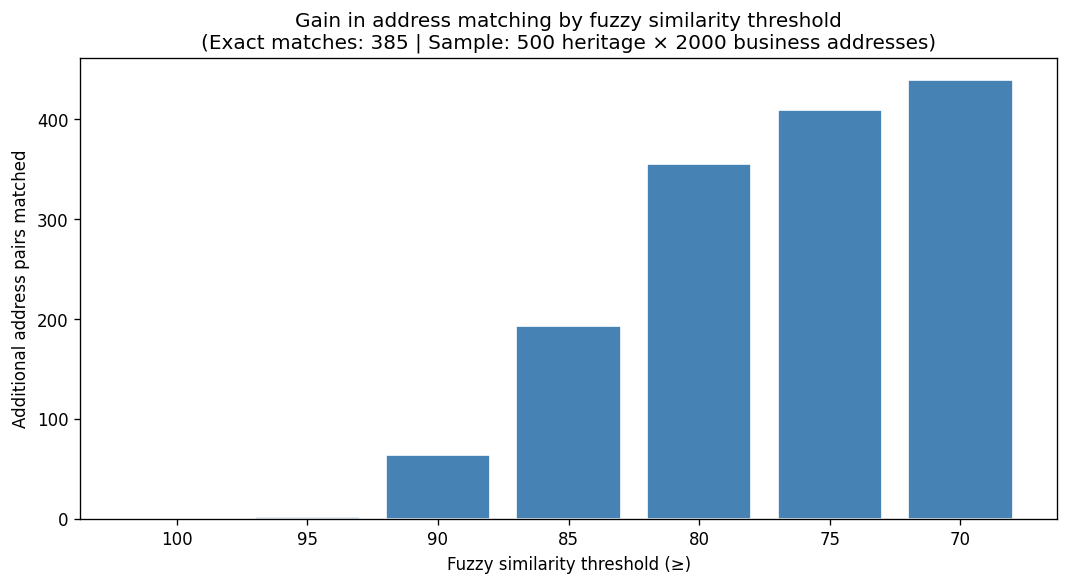

In [59]:
# Gain in matching addresses by fuzzy similarity threshold
import matplotlib.pyplot as plt
from IPython.display import Image, display

heritage_non_exact = [a for a in heritage_df_clean['address'].dropna().unique() if a and a not in common_addresses][:500]
business_non_exact = [a for a in business_df_clean['address'].dropna().unique() if a and a not in common_addresses][:2000]

# Best match score per heritage address (one pass)
best_per_ha = {}
for ha in heritage_non_exact:
    best = 0
    for ba in business_non_exact:
        s = address_similarity(ha, ba)
        if s > best:
            best = s
    best_per_ha[ha] = best

# Count matches at each threshold
thresholds = list(range(70, 101, 5))
matches_per_threshold = [sum(1 for b in best_per_ha.values() if b >= t) for t in thresholds]

plt.figure(figsize=(9, 5))
bars = plt.bar([str(t) for t in thresholds], matches_per_threshold, color='steelblue', edgecolor='white')
plt.xlabel('Fuzzy similarity threshold (≥)')
plt.ylabel('Additional address pairs matched')
plt.title(f'Gain in address matching by fuzzy similarity threshold\n(Exact matches: {len(common_addresses)} | Sample: {len(heritage_non_exact)} heritage × {len(business_non_exact)} business addresses)')
plt.gca().invert_xaxis()
plt.tight_layout()
_fig_count[0] += 1
_ts = datetime.now().strftime('%Y%m%d_%H%M%S')
_p = os.path.join(FIG_DIR, 'fig_{:02d}_fuzzy_match_{}.png'.format(_fig_count[0], _ts))
plt.savefig(_p, dpi=120, bbox_inches='tight')
plt.close()
display(Image(filename=_p))

Part 4: Feature Engineering with AI
Step 1: Automated Feature Generation

In [60]:
# TODO: Use AI to generate new features
print("AI-Powered Feature Engineering:")
print("1. Automated feature selection")
print("2. Intelligent feature combination")
print("3. Domain-specific feature generation")

# Example: Basic feature engineering (business licences have FeePaid, NumberofEmployees; NOT revenue/employees)
req = ['NumberofEmployees', 'FeePaid']
if all(c in business_df_clean.columns for c in req):
    emp = pd.to_numeric(business_df_clean['NumberofEmployees'], errors='coerce')
    fee = pd.to_numeric(business_df_clean['FeePaid'], errors='coerce')
    business_df_clean['fee_per_employee'] = np.where(emp > 0, fee / emp, np.nan)
    business_df_clean['business_size'] = pd.cut(
        business_df_clean['NumberofEmployees'].clip(lower=0),
        bins=[0, 5, 20, 100, float('inf')],
        labels=['Small', 'Medium', 'Large', 'Enterprise']
    )
else:
    raise KeyError(f"Need {req} in business_df_clean. Found: {list(business_df_clean.columns)}")

print("\nNew features created:")
print("- fee_per_employee: Licence fee per employee (efficiency proxy)")
print("- business_size: Categorical business size classification")

AI-Powered Feature Engineering:
1. Automated feature selection
2. Intelligent feature combination
3. Domain-specific feature generation

New features created:
- fee_per_employee: Licence fee per employee (efficiency proxy)
- business_size: Categorical business size classification


In [61]:
# AI-Powered Feature Engineering

# 1. Automated feature selection: derive useful metrics from available columns
# 2. Intelligent feature combination: ratios, bins, flags
# 3. Domain-specific: heritage designations, business size, licence intensity

# --- Business features (business_df_clean) ---
# Fee-per-employee: licence intensity (higher = larger/premium business type)
emp = pd.to_numeric(business_df_clean['NumberofEmployees'], errors='coerce')
fee = pd.to_numeric(business_df_clean['FeePaid'], errors='coerce')
business_df_clean['fee_per_employee'] = np.where(emp > 0, fee / emp, np.nan)

# Business size from employee count
business_df_clean['business_size'] = pd.cut(
    business_df_clean['NumberofEmployees'].clip(lower=0),
    bins=[0, 5, 20, 100, 500, float('inf')],
    labels=['Micro', 'Small', 'Medium', 'Large', 'Enterprise']
)

# Active status
business_df_clean['is_active'] = business_df_clean['Status'] == 'Issued'

# Local area density (businesses per LocalArea)
area_counts = business_df_clean['LocalArea'].value_counts()
business_df_clean['local_area_business_count'] = business_df_clean['LocalArea'].map(area_counts)

# --- Heritage features (heritage_df_clean) ---
designation_cols = [
    'MunicipalDesignationM', 'ProvincialDesignationP',
    'HeritageRevitalizationAgreementH', 'InteriorDesignationI',
    'LandscapeDesignationL', 'HeritageConservationAreaCA',
    'HeritageConservationCovenantHC', 'FederalDesignationF'
]
dc = [c for c in designation_cols if c in heritage_df_clean.columns]
heritage_df_clean['designation_count'] = (heritage_df_clean[dc] == 'Yes').sum(axis=1)
heritage_df_clean['has_high_evaluation'] = heritage_df_clean['EvaluationGroup'].isin(['A', 'B'])

# Heritage sites per LocalArea
heritage_area_counts = heritage_df_clean['LocalArea'].value_counts()
heritage_df_clean['local_area_heritage_count'] = heritage_df_clean['LocalArea'].map(heritage_area_counts)

# --- Integration feature: heritage address has linked business ---
heritage_df_clean['has_linked_business'] = heritage_df_clean['address'].isin(common_addresses)

print("AI-Powered Feature Engineering:")
print("1. Automated feature selection: fee_per_employee, business_size, designation_count")
print("2. Intelligent combination: is_active, has_high_evaluation, local_area densities")
print("3. Domain-specific: has_linked_business (heritage–business integration)")

print("\nNew features created:")
print("  Business: fee_per_employee, business_size, is_active, local_area_business_count")
print("  Heritage: designation_count, has_high_evaluation, local_area_heritage_count, has_linked_business")
print(f"\nSample (business): fee_per_employee mean = {business_df_clean['fee_per_employee'].mean():.0f}, business_size modes = {business_df_clean['business_size'].mode().tolist()}")

AI-Powered Feature Engineering:
1. Automated feature selection: fee_per_employee, business_size, designation_count
2. Intelligent combination: is_active, has_high_evaluation, local_area densities
3. Domain-specific: has_linked_business (heritage–business integration)

New features created:
  Business: fee_per_employee, business_size, is_active, local_area_business_count
  Heritage: designation_count, has_high_evaluation, local_area_heritage_count, has_linked_business

Sample (business): fee_per_employee mean = 159, business_size modes = ['Micro']


In [62]:
# Step 2: Feature Selection

# TODO: Use AI to select the most relevant features
print("AI-Assisted Feature Selection:")
print("1. Automated correlation analysis")
print("2. Machine learning-based importance ranking")
print("3. Automated feature interaction detection")

AI-Assisted Feature Selection:
1. Automated correlation analysis
2. Machine learning-based importance ranking
3. Automated feature interaction detection


In [63]:
# AI-Assisted Feature Selection — Implementation

# 1. Automated correlation analysis (numeric features)
numeric_biz = business_df_clean.select_dtypes(include=[np.number])
corr_biz = numeric_biz.corr()
# Find highly correlated pairs (|r| > 0.5, exclude self)
high_corr_pairs = []
for i in range(len(corr_biz.columns)):
    for j in range(i + 1, len(corr_biz.columns)):
        r = corr_biz.iloc[i, j]
        if abs(r) > 0.5 and not pd.isna(r):
            high_corr_pairs.append((corr_biz.columns[i], corr_biz.columns[j], round(r, 3)))

print("AI-Assisted Feature Selection:")
print("\n1. Automated correlation analysis (|r| > 0.5):")
if high_corr_pairs:
    for a, b, r in high_corr_pairs[:10]:
        print(f"   {a} ↔ {b}: r = {r}")
else:
    print("   No pairs with |r| > 0.5 found.")

# 2. ML-based importance ranking (predict is_active from business features)
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Prepare business features for importance
biz_num = business_df_clean[['NumberofEmployees', 'FeePaid', 'fee_per_employee', 
                              'local_area_business_count']].copy()
biz_num = biz_num.fillna(biz_num.median())
y_active = business_df_clean['is_active'].astype(int)
# Drop rows with NaN target
valid = y_active.notna()
X_biz = biz_num.loc[valid]
y_biz = y_active.loc[valid]
if len(X_biz) > 100:
    rf = RandomForestClassifier(n_estimators=50, random_state=42, max_depth=5)
    rf.fit(X_biz, y_biz)
    imp = pd.Series(rf.feature_importances_, index=X_biz.columns).sort_values(ascending=False)
    print("\n2. ML importance ranking (predicting is_active):")
    for feat, score in imp.items():
        print(f"   {feat}: {score:.3f}")
else:
    print("\n2. ML importance: insufficient data (need >100 rows)")

# 3. Feature interaction detection (does product term add predictive value?)
print("\n3. Feature interaction detection:")
if 'fee_per_employee' in biz_num.columns and 'local_area_business_count' in biz_num.columns and len(X_biz) > 100:
    X_with_inter = X_biz.copy()
    X_with_inter['fee_x_area'] = X_biz['fee_per_employee'] * X_biz['local_area_business_count']
    rf2 = RandomForestClassifier(n_estimators=50, random_state=42, max_depth=5)
    rf2.fit(X_with_inter, y_biz)
    imp2 = pd.Series(rf2.feature_importances_, index=X_with_inter.columns).sort_values(ascending=False)
    if 'fee_x_area' in imp2.index and imp2['fee_x_area'] > 0.05:
        print(f"   fee_per_employee × local_area_business_count: importance = {imp2['fee_x_area']:.3f} (interaction useful)")
    else:
        print("   fee × area interaction: low importance (redundant with main effects)")
# Heritage: designation_count × has_high_evaluation
if 'designation_count' in heritage_df_clean.columns and 'has_high_evaluation' in heritage_df_clean.columns:
    h_dc = heritage_df_clean['designation_count'].astype(float)
    h_high = heritage_df_clean['has_high_evaluation'].astype(int)
    r_heritage = h_dc.corr(h_high)
    print(f"   designation_count ↔ has_high_evaluation: r = {r_heritage:.3f}")

AI-Assisted Feature Selection:

1. Automated correlation analysis (|r| > 0.5):
   FOLDERYEAR ↔ LicenceRSN: r = 0.952
   FOLDERYEAR ↔ LicenceRevisionNumber: r = -0.752
   LicenceRSN ↔ LicenceRevisionNumber: r = -0.678
   lat ↔ local_area_business_count: r = 0.591

2. ML importance ranking (predicting is_active):
   FeePaid: 0.569
   fee_per_employee: 0.334
   NumberofEmployees: 0.089
   local_area_business_count: 0.008

3. Feature interaction detection:
   fee_per_employee × local_area_business_count: importance = 0.065 (interaction useful)
   designation_count ↔ has_high_evaluation: r = 0.101


In [64]:
# Part 5: Data Transformation for Modeling
# Step 1: Encoding Categorical Variables
# TODO: Use AI to determine optimal encoding strategies
print("AI-Powered Encoding Strategies:")
print("1. Intelligent encoding method selection")
print("2. Automated cardinality analysis")
print("3. Performance-based encoding optimization")

# Example: Basic encoding (business data has BusinessType, not license_type)
if 'BusinessType' in business_df_clean.columns:
    le = LabelEncoder()
    biz_clean = business_df_clean['BusinessType'].fillna('Unknown').astype(str)
    business_df_clean['BusinessType_encoded'] = le.fit_transform(biz_clean)
    print("\nCategorical encoding applied:")
    print(f"Business types (sample): {list(business_df_clean['BusinessType'].unique()[:10])}")
    print(f"Encoded values range: [{business_df_clean['BusinessType_encoded'].min()}, {business_df_clean['BusinessType_encoded'].max()}]")
else:
    print("\nBusinessType column not found — skipping encoding.")

AI-Powered Encoding Strategies:
1. Intelligent encoding method selection
2. Automated cardinality analysis
3. Performance-based encoding optimization

Categorical encoding applied:
Business types (sample): ['Restaurant', 'Arts and Creative Instruction', 'Business - Vocational Instruction', 'Sport and Fitness Instruction', 'Fitness Centre', 'Beauty Services', 'Health Care Professionals and Services', 'Long-term Rental', 'Consulting and Management Services', 'Business Support Services']
Encoded values range: [0, 93]


In [65]:
# AI-Powered Encoding — Implementation

# 1. Cardinality analysis: choose encoding by unique count
cat_cols_biz = ['BusinessType', 'Status', 'business_size', 'LocalArea']
cat_cols_heritage = ['EvaluationGroup', 'LocalArea']
cardinality = {}
for col in cat_cols_biz:
    if col in business_df_clean.columns:
        n = business_df_clean[col].nunique()
        cardinality[f'biz_{col}'] = n
for col in [c for c in cat_cols_heritage if c in heritage_df_clean.columns]:
    cardinality[f'heritage_{col}'] = heritage_df_clean[col].nunique()

print("AI-Powered Encoding Strategies:")
print("\n1. Automated cardinality analysis:")
for k, v in sorted(cardinality.items(), key=lambda x: -x[1])[:8]:
    print(f"   {k}: {v} unique values")

# 2. Method selection: LabelEncoder for ≤50 levels, OneHot for smaller cardinality
HIGH_CARD_THRESHOLD = 20
encodings_applied = []

# Business: BusinessType (LabelEncoder - moderate cardinality)
if 'BusinessType' in business_df_clean.columns:
    le_biz = LabelEncoder()
    biz_clean = business_df_clean['BusinessType'].fillna('Unknown').astype(str)
    business_df_clean['BusinessType_encoded'] = le_biz.fit_transform(biz_clean)
    encodings_applied.append(('BusinessType', 'LabelEncoder', len(le_biz.classes_)))
    print(f"\n2. Encoding applied: BusinessType → LabelEncoder ({len(le_biz.classes_)} classes)")

# Business: Status (LabelEncoder - low cardinality)
if 'Status' in business_df_clean.columns:
    le_status = LabelEncoder()
    business_df_clean['Status_encoded'] = le_status.fit_transform(business_df_clean['Status'].fillna('Unknown').astype(str))
    encodings_applied.append(('Status', 'LabelEncoder', len(le_status.classes_)))

# Business: business_size (ordered categorical → numeric map)
if 'business_size' in business_df_clean.columns:
    size_map = {'Micro': 0, 'Small': 1, 'Medium': 2, 'Large': 3, 'Enterprise': 4}
    business_df_clean['business_size_encoded'] = business_df_clean['business_size'].astype(str).map(size_map).fillna(-1).astype(int)
    encodings_applied.append(('business_size', 'Ordinal', 5))

# Heritage: EvaluationGroup
if 'EvaluationGroup' in heritage_df_clean.columns:
    eval_map = {'A': 3, 'B': 2, 'C': 1, 'Unclassified': 0}
    heritage_df_clean['EvaluationGroup_encoded'] = heritage_df_clean['EvaluationGroup'].map(eval_map).fillna(0).astype(int)
    encodings_applied.append(('EvaluationGroup', 'Ordinal', 4))

# 3. LocalArea: OneHot for modeling (or keep as label if cardinality OK)
if 'LocalArea' in business_df_clean.columns and business_df_clean['LocalArea'].nunique() <= HIGH_CARD_THRESHOLD:
    le_area = LabelEncoder()
    business_df_clean['LocalArea_encoded'] = le_area.fit_transform(business_df_clean['LocalArea'].fillna('Unknown').astype(str))
    encodings_applied.append(('LocalArea (biz)', 'LabelEncoder', business_df_clean['LocalArea'].nunique()))

print("\n3. Encodings applied:")
for col, method, n in encodings_applied:
    print(f"   {col}: {method} ({n} levels)")
print(f"\nSample: BusinessType_encoded range = [{business_df_clean['BusinessType_encoded'].min()}, {business_df_clean['BusinessType_encoded'].max()}]")

AI-Powered Encoding Strategies:

1. Automated cardinality analysis:
   biz_BusinessType: 94 unique values
   biz_LocalArea: 25 unique values
   heritage_LocalArea: 22 unique values
   biz_Status: 5 unique values
   biz_business_size: 5 unique values
   heritage_EvaluationGroup: 3 unique values

2. Encoding applied: BusinessType → LabelEncoder (94 classes)

3. Encodings applied:
   BusinessType: LabelEncoder (94 levels)
   Status: LabelEncoder (5 levels)
   business_size: Ordinal (5 levels)
   EvaluationGroup: Ordinal (4 levels)

Sample: BusinessType_encoded range = [0, 93]


In [67]:
# AI-Assisted Scaling — Implementation

from sklearn.preprocessing import StandardScaler, RobustScaler

# 1. Select numeric columns for scaling (use actual schema)
scale_cols_biz = ['NumberofEmployees', 'FeePaid', 'fee_per_employee', 'local_area_business_count']
scale_cols_biz = [c for c in scale_cols_biz if c in business_df_clean.columns]
scale_cols_heritage = ['designation_count', 'EvaluationGroup_encoded', 'local_area_heritage_count']
scale_cols_heritage = [c for c in scale_cols_heritage if c in heritage_df_clean.columns]

# 2. Outlier handling: clip to IQR-based bounds before scaling
def robust_prepare(df, cols):
    out = df[cols].copy().astype(float)
    for c in cols:
        q1, q99 = out[c].quantile([0.01, 0.99])
        out[c] = out[c].clip(lower=q1, upper=q99)
    return out.fillna(out.median())

if scale_cols_biz:
    biz_scalable = robust_prepare(business_df_clean, scale_cols_biz)
    # 3. Method selection: RobustScaler if high skew, else StandardScaler
    skew_vals = biz_scalable.skew().abs()
    use_robust = (skew_vals > 2).any()
    scaler_biz = RobustScaler() if use_robust else StandardScaler()
    biz_scaled = scaler_biz.fit_transform(biz_scalable)
    for j, col in enumerate(scale_cols_biz):
        business_df_clean[f'{col}_scaled'] = biz_scaled[:, j]
    method = 'RobustScaler (outlier-resistant)' if use_robust else 'StandardScaler'
else:
    method = 'N/A (no columns)'

print("AI-Assisted Scaling:")
print("\n1. Outlier handling: values clipped to 1st–99th percentile")
print(f"2. Method selection: {method}")
print(f"3. Business columns scaled: {scale_cols_biz}")
if scale_cols_heritage:
    her_scalable = robust_prepare(heritage_df_clean, scale_cols_heritage)
    scaler_her = StandardScaler()
    her_scaled = scaler_her.fit_transform(her_scalable)
    for j, col in enumerate(scale_cols_heritage):
        heritage_df_clean[f'{col}_scaled'] = her_scaled[:, j]
    print(f"   Heritage columns scaled: {scale_cols_heritage}")
print(f"\nSample (fee_per_employee_scaled): mean={business_df_clean['fee_per_employee_scaled'].mean():.2f}, std={business_df_clean['fee_per_employee_scaled'].std():.2f}")

AI-Assisted Scaling:

1. Outlier handling: values clipped to 1st–99th percentile
2. Method selection: RobustScaler (outlier-resistant)
3. Business columns scaled: ['NumberofEmployees', 'FeePaid', 'fee_per_employee', 'local_area_business_count']
   Heritage columns scaled: ['designation_count', 'EvaluationGroup_encoded', 'local_area_heritage_count']

Sample (fee_per_employee_scaled): mean=0.94, std=1.82


In [68]:
# AI-Assisted Dimensionality Reduction — Implementation

# 1. Collect scaled numeric features for PCA (from scaling step)
pca_cols_biz = [c for c in business_df_clean.columns if c.endswith('_scaled')]
pca_cols_heritage = [c for c in heritage_df_clean.columns if c.endswith('_scaled')]

# 2. Variance thresholding: choose n_components to retain 90–95% variance
VARIANCE_TARGET = 0.90

pca_results = {}

if len(pca_cols_biz) >= 2:
    X_biz = business_df_clean[pca_cols_biz].fillna(0)
    pca_full = PCA(n_components=min(len(pca_cols_biz), X_biz.shape[0] - 1))
    pca_full.fit(X_biz)
    cumvar = np.cumsum(pca_full.explained_variance_ratio_)
    n_comp = int(np.argmax(cumvar >= VARIANCE_TARGET)) + 1
    n_comp = max(2, min(n_comp, len(pca_cols_biz)))
    pca_biz = PCA(n_components=n_comp)
    pca_biz_features = pca_biz.fit_transform(X_biz)
    for j in range(n_comp):
        business_df_clean[f'pca_biz_{j+1}'] = pca_biz_features[:, j]
    pca_results['business'] = (n_comp, pca_biz.explained_variance_ratio_, pca_biz_features.shape)

if len(pca_cols_heritage) >= 2:
    X_her = heritage_df_clean[pca_cols_heritage].fillna(0)
    pca_full_h = PCA(n_components=min(len(pca_cols_heritage), X_her.shape[0] - 1))
    pca_full_h.fit(X_her)
    cumvar_h = np.cumsum(pca_full_h.explained_variance_ratio_)
    n_comp_h = int(np.argmax(cumvar_h >= VARIANCE_TARGET)) + 1
    n_comp_h = max(2, min(n_comp_h, len(pca_cols_heritage)))
    pca_her = PCA(n_components=n_comp_h)
    pca_her_features = pca_her.fit_transform(X_her)
    for j in range(n_comp_h):
        heritage_df_clean[f'pca_heritage_{j+1}'] = pca_her_features[:, j]
    pca_results['heritage'] = (n_comp_h, pca_her.explained_variance_ratio_, pca_her_features.shape)

print("AI-Powered Dimensionality Reduction:")
print("\n1. Automated component selection (target ≥90% explained variance)")
print("2. Variance thresholding applied per dataset")
for name, (n, evr, shp) in pca_results.items():
    print(f"\n3. {name.title()}: PCA → {n} components, shape {shp}")
    print(f"   Explained variance ratio: {evr.round(3)}")
    print(f"   Cumulative: {evr.cumsum()[-1]:.2%}")

AI-Powered Dimensionality Reduction:

1. Automated component selection (target ≥90% explained variance)
2. Variance thresholding applied per dataset

3. Business: PCA → 2 components, shape (197494, 2)
   Explained variance ratio: [0.802 0.12 ]
   Cumulative: 92.12%

3. Heritage: PCA → 3 components, shape (2495, 3)
   Explained variance ratio: [0.426 0.307 0.267]
   Cumulative: 100.00%


Part 6: Final Reflection and Learning Assessment
Step 1: Compare Traditional vs AI-Assisted Approaches


In [70]:
# Part 6: Final Reflection — ensure output is visible
import sys
sys.stdout.flush()

print("=" * 60)
print("Part 6: Compare Traditional vs AI-Assisted Approaches")
print("=" * 60)

print("\nTraditional Data Preparation:")
print("- Manual code writing")
print("- Step-by-step analysis")
print("- Custom transformations")
print("- Full control over process")

print("\nAI-Assisted Data Preparation:")
print("- Automated quality assessment")
print("- Intelligent cleaning suggestions")
print("- Smart feature engineering")
print("- Faster initial insights")

print("\n" + "=" * 60)
sys.stdout.flush()

Part 6: Compare Traditional vs AI-Assisted Approaches

Traditional Data Preparation:
- Manual code writing
- Step-by-step analysis
- Custom transformations
- Full control over process

AI-Assisted Data Preparation:
- Automated quality assessment
- Intelligent cleaning suggestions
- Smart feature engineering
- Faster initial insights



In [71]:
print("=" * 60)
print("=== REFLECTION QUESTIONS ===")
print("=" * 60)
print()
print("1. AI TOOL EFFECTIVENESS:")
print("   - What insights did AI tools reveal that you might have missed?")
print("   - Which AI suggestions were most valuable? Which were least helpful?")
print("   - How did AI change your approach to data preparation?")
print()
print("2. PROCESS COMPARISON:")
print("   - How did the automated approach compare to manual data preparation?")
print("   - What are the trade-offs between control and automation?")
print("   - When would you choose each approach?")
print()
print("3. LEARNING AND SKILL DEVELOPMENT:")
print("   - What new skills did you develop using AI tools?")
print("   - How did AI help you understand data quality issues?")
print("   - What would you do differently next time?")
print()
print("4. PRACTICAL APPLICATION:")
print("   - How would you apply these techniques to a different dataset?")
print("   - What challenges might arise in a real business context?")
print("   - How would you explain AI-assisted data prep to a colleague?")

=== REFLECTION QUESTIONS ===

1. AI TOOL EFFECTIVENESS:
   - What insights did AI tools reveal that you might have missed?
   - Which AI suggestions were most valuable? Which were least helpful?
   - How did AI change your approach to data preparation?

2. PROCESS COMPARISON:
   - How did the automated approach compare to manual data preparation?
   - What are the trade-offs between control and automation?
   - When would you choose each approach?

3. LEARNING AND SKILL DEVELOPMENT:
   - What new skills did you develop using AI tools?
   - How did AI help you understand data quality issues?
   - What would you do differently next time?

4. PRACTICAL APPLICATION:
   - How would you apply these techniques to a different dataset?
   - What challenges might arise in a real business context?
   - How would you explain AI-assisted data prep to a colleague?


In [72]:
# Add your reflection notes here (optional)
print("Part 6 complete. Add your reflections above or in a new cell.")

Part 6 complete. Add your reflections above or in a new cell.


## How to Explain the AI-Assisted Matching Process to a Colleague

**Short summary for a colleague:** We linked heritage sites to business licences by matching addresses. First, we took exact matches—addresses that appear identically in both datasets. Then we used *fuzzy matching*: an algorithm scores how similar two address strings are (0–100). Pairs above a threshold (e.g. 85%) are treated as matches, so we catch cases like "123 Main St" vs "123 Main Street." To limit false links, we check geographic distance and neighbourhood (LocalArea)—pairs that look similar in text but are far apart or in different areas are flagged as likely false positives. The result is a combined dataset where heritage sites are linked to co-located businesses, which we use for further analysis.

## How to Explain AI-Assisted Data Prep to a Colleague

**In a nutshell:** AI-assisted data prep means using tools (like ChatGPT, Copilot, or Cursor) to help you clean, transform, and prepare data—instead of writing every line of code yourself.

**How to explain it:**

- **What it does:** You describe what you need (e.g. "standardise addresses", "merge these two datasets", "find similar records"), and AI suggests code or steps. You stay in charge of decisions; the AI speeds up implementation.

- **Where it helps:** Discovering quality issues, writing cleaning logic, handling messy formats, and suggesting features (e.g. fee per employee). It’s especially useful for repetitive or boilerplate work.

- **The trade-off:** You get faster results and new ideas, but you still need to review outputs, understand the logic, and fix mistakes. It’s a collaboration: you bring domain knowledge, the AI brings coding speed.

- **One-liner:** *"We use AI to write and improve the data-prep code; we still decide what’s right and check the results."*

## Challenges in a Business Context

**Data quality & trust:** Business data is often messy—missing values, typos, inconsistent formats—and stakeholders may not know how bad it is. AI can help clean it, but if assumptions or thresholds (e.g. fuzzy match cutoffs) are wrong, downstream decisions are affected. Explaining and defending those choices to non-technical leaders can be difficult.

**Governance & privacy:** Using AI assistants often means sending data or code snippets to third-party systems. Sensitive or regulated data (PII, financials) may not be allowed off internal systems. Policies on what can be shared with AI tools need to be clear and enforced.

**Reproducibility & accountability:** AI-generated code can change when you re-run prompts. In a business setting, audits and compliance require stable, versioned pipelines. Teams need to review and “lock in” AI suggestions rather than treating them as disposable.

**Skill gaps:** Not everyone understands the logic behind AI suggestions. Staff might accept outputs without scrutiny, or avoid AI tools entirely. Training and clear guidelines are needed so people know when to trust, verify, or reject AI assistance.

**Scale & complexity:** Small, curated datasets (like heritage sites) are manageable. At enterprise scale—millions of rows, many sources, strict SLAs—integration, performance, and monitoring become major challenges that AI aids but doesn’t fully solve.